# Summary statistics of blood+immune datasets

In [1]:
import os

import anndata
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from os.path import join

In [2]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"

In [3]:
summary = {"dataset": [], "n_cells": [], "n_celltypes": [], "n_celltypes_author": [], "cts": []}

for dataset in sorted(os.listdir(DATA_PATH)):
    if dataset.endswith(".h5ad"):
        adata = anndata.read_h5ad(join(DATA_PATH, dataset), backed="r")
        summary["dataset"].append(dataset.removesuffix(".h5ad"))
        summary["n_cells"].append(adata.shape[0])
        summary["n_celltypes"].append(adata.obs.cell_type.nunique())
        summary["n_celltypes_author"].append(adata.obs.cell_type_author.nunique())
        summary["cts"].append(adata.obs.cell_type_author.unique().tolist())

pd.DataFrame(summary).set_index("dataset")

,n_cells,n_celltypes,n_celltypes_author,cts
dataset,,,,
03f821b4-87be-4ff4-b65a-b5fc00061da7_Airway,236977,40,59,"[Goblet 2 BPIFA2+, B mem exhausted, T gd, T CD..."
03f821b4-87be-4ff4-b65a-b5fc00061da7_PBMC,422220,30,42,"[Monocyte CD14, T CD4 helper, T CD8 naive, T C..."
0c8a364b-97b5-4cc8-a593-23c38c6f0ac5,89637,27,45,"[cvLSEC, LAM-like, lrNK, C-Hepato2, Arterial, ..."
0c8a364b-97b5-4cc8-a593-23c38c6f0ac5_Kupffer,89637,27,47,"[cvLSEC, LAM-like, lrNK, C-Hepato2, Arterial, ..."
0c8a364b-97b5-4cc8-a593-23c38c6f0ac5_LYVE1_macrophages,89637,27,47,"[cvLSEC, LAM-like, lrNK, C-Hepato2, Arterial, ..."
0c8a364b-97b5-4cc8-a593-23c38c6f0ac5_macrophages,89637,27,47,"[cvLSEC, LAM-like, lrNK, C-Hepato2, Arterial, ..."
0f528c8a-a25c-4840-8fa3-d156fa11086f,225177,25,54,"[IMCD, VSMC/P, dVSMC, PC, DTL1, EC-LYM, CNT-PC..."
0f528c8a-a25c-4840-8fa3-d156fa11086f_MAIT,225177,25,55,"[IMCD, VSMC/P, dVSMC, PC, DTL1, EC-LYM, CNT-PC..."
0f528c8a-a25c-4840-8fa3-d156fa11086f_Treg,225177,25,55,"[IMCD, VSMC/P, dVSMC, PC, DTL1, EC-LYM, CNT-PC..."


## Visualization `7d7cabfd-1d1f-40af-96b7-26a0825a306d`

In [9]:
adata = sc.read_h5ad(join(DATA_PATH, "7d7cabfd-1d1f-40af-96b7-26a0825a306d.h5ad"))

In [10]:
adata.obs.ct2.value_counts().to_frame()

,count
ct2,
cM,159044
T8_Mem,79449
T4_Naive,73989
T4_Mem,63683
B_Naive,43200
NK_CD16+,36313
ncM,23298
T8_Naive,21410
NKT,21136


In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

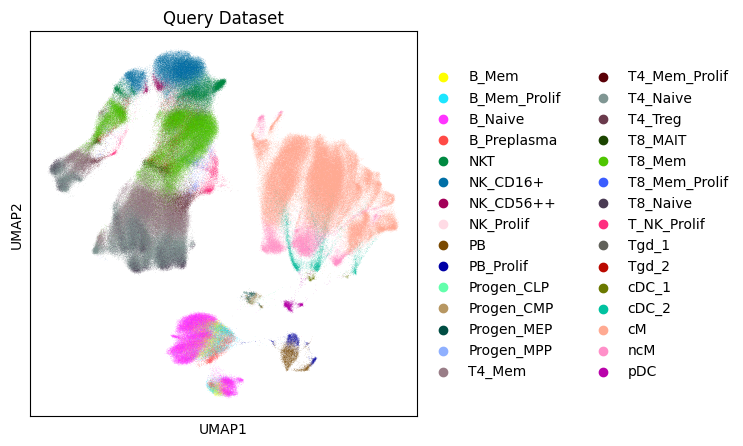

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.umap(adata, color="ct2", ax=ax, title="Query Dataset")

## Visualization `ced320a1-29f3-47c1-a735-513c7084d508`

In [6]:
adata = sc.read_h5ad(join(DATA_PATH, "ced320a1-29f3-47c1-a735-513c7084d508.h5ad"))

In [8]:
adata.obs.cell_type_author.value_counts().to_frame()

,count
cell_type_author,
CD14+_Monocyte,177896
CD4+_T_naive,143515
CD16+_NK,135960
CD4+_T_cm,111905
CD8+_T_naive,72925
CD8+_T_GZMB+,63787
CD16+_Monocyte,41913
CD8+_T_GZMK+,39218
naive_B,32515


In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

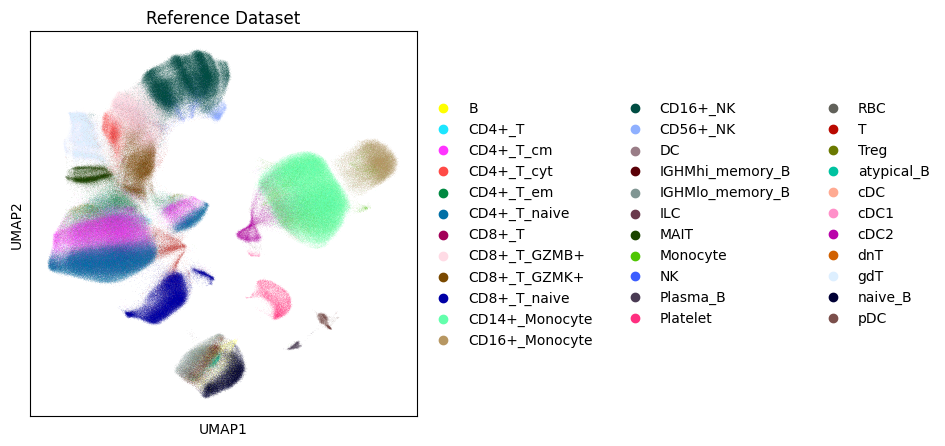

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.umap(adata, color="cell_type_author", ax=ax, title="Reference Dataset")

## Visualization `f6c50495-3361-40ed-a819-fb9644396ed9`

In [9]:
adata = sc.read_h5ad(join(DATA_PATH, "f6c50495-3361-40ed-a819-fb9644396ed9.h5ad"))

In [10]:
adata.obs.cell_type_author.value_counts().to_frame()

,count
cell_type_author,
CD4 Naive,24063
CD14 Mono,23957
HSC,12641
CD4 Central Memory,12152
Early GMP,11432
Cycling Progenitor,9366
CD8 Naive,8502
CD8 Effector Memory 2,8486
Pro-Erythroblast,7390


In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

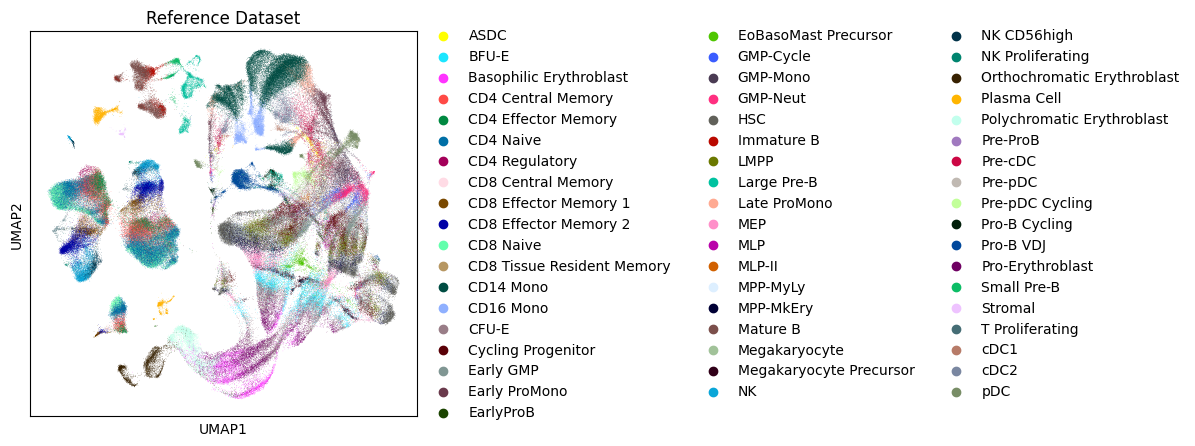

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.umap(adata, color="cell_type_author", ax=ax, title="Reference Dataset")